<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Entregable_P2_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---

## Trabajo práctico entregable - Parte 2

## Grupo 3:


*   BAGGINI, Mariano
*   DA SILVA, Rocio
*   GRUZYCKI, Sergio
*   NEDEL, Agustina  

NOTA: Corregir Delta de Glass por D de Cohen

In [1]:
import io
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import tt_ind_solve_power
from scipy.stats import ttest_ind

sns.set_context('talk')

## Ejercicio 1: Estimación

Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la diferencia entre la **media** del *salario neto* para *hombres* y la **media** del *salario neto* para *mujeres* (diferencia de medias entre el grupoA y grupoB).

¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

### Resolución del ejercicio 1

1. Se realiza la misma limpieza hecha en la primera parte del entregable, acotando el estudio a perfiles con dedicación Full-Time.

2. Se seleccionan las siguientes columnas relevantes:

* caa

### Lectura del dataset


In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)
df_raw = df.copy()
df_raw.head(3)

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [3]:
# Observación general de los datos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 60 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4939 non-null   object 
 1   work_dedication                                       4939 non-null   object 
 2   work_contract_type                                    4939 non-null   object 
 3   salary_monthly_BRUTO                                  4939 non-null   float64
 4   salary_monthly_NETO                                   4717 non-null   float64
 5   salary_in_usd                                         1583 non-null   object 
 6   salary_last_dollar_value                              1028 non-null   object 
 7   salary_has_bonus                                      4939 non-null   object 
 8   salary_bonus_tied_to                                  4938

#### Análisis **sin** discriminar por *seniority*.

Limpieza del dataset + estimación de brecha salarial neta + IC95%

In [4]:
# Columnas a utilizar en el analisis
relevant_columns = ['salary_monthly_BRUTO', 'salary_monthly_NETO',
                    'work_dedication', 'work_seniority', 'profile_gender']

In [5]:
# Limpieza sobre columnas relevantes
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.dropna(subset=relevant_columns)
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4938
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   salary_monthly_BRUTO  4715 non-null   float64
 1   salary_monthly_NETO   4715 non-null   float64
 2   work_dedication       4715 non-null   object 
 3   work_seniority        4715 non-null   object 
 4   profile_gender        4715 non-null   object 
dtypes: float64(2), object(3)
memory usage: 221.0+ KB


In [6]:
# Limpieza de extremos con percentiles (1% superior e inferior)
p01 = df_raw['salary_monthly_NETO'].quantile(0.01)
p99 = df_raw['salary_monthly_NETO'].quantile(0.99)

df_bounded = df_raw[
    (df_raw['salary_monthly_NETO'] >= p01) &
    (df_raw['salary_monthly_NETO'] <= p99)
].copy()

# Consideramos dedicacion Full-Time unicamente
df_bounded = df_bounded.drop(df_bounded[df_bounded["work_dedication"] == "Part-Time"].index)

In [7]:
# Unifico generos
df_bounded.loc[:,'profile_g'] = df_bounded.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [8]:
# Identifico hombres y mujeres en arreglos independientes
is_man = df_bounded.profile_g == 'Varón cis'
is_woman = df_bounded.profile_g == 'Mujer cis'

groupA = df_bounded[is_man].salary_monthly_NETO
groupB  = df_bounded[is_woman].salary_monthly_NETO

# Descripción de arreglos

print("=" * 55)
print("HOMBRES - SALARIO NETO")
print("=" * 55)
print(groupA.describe().round(0))

print("\n" + "=" * 55)
print("MUJERES - SALARIO NETO")
print("=" * 55)
print(groupB.describe().round(0))

HOMBRES - SALARIO NETO
count        3473.0
mean      3345187.0
std       1906711.0
min        390000.0
25%       2000000.0
50%       2934389.0
75%       4200000.0
max      11820000.0
Name: salary_monthly_NETO, dtype: float64

MUJERES - SALARIO NETO
count         870.0
mean      2764167.0
std       1507548.0
min        415000.0
25%       1697000.0
50%       2400000.0
75%       3500000.0
max      10000000.0
Name: salary_monthly_NETO, dtype: float64


Estimador puntual: Diferencia de medias salariales

In [9]:
alpha = 0.05  # Nivel de significación (1 - alpha = 95% confianza)

# Calcular medias por grupo y desviaciones estándar
x_h = np.mean(groupA)  # Media hombres
x_m = np.mean(groupB)  # Media mujeres
s_h = np.std(groupA, ddof=1)  # Desviación estándar hombres
s_m = np.std(groupB, ddof=1)  # Desviación estándar mujeres
n_h = len(groupA)  # Tamaño muestral hombres
n_m = len(groupB)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Hombres - Mujeres): {diff_medias:.2f}")

Estimación puntual de la diferencia de medias (Hombres - Mujeres): 581019.61


Diferencia entre medias obtenida de $581K (sin discriminar seniority).

Intervalo de confianza al 95%

In [10]:
# Intervalo de confianza usando t de Welch (no asume varianzas iguales)
# Error estándar de la diferencia
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad (aproximación de Welch)
df = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1)))

# Valor crítico para el intervalo de confianza
t_crit = stats.t.ppf(1 - alpha / 2, df)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error
print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Intervalo de confianza al 95.0%: (462372.78, 699666.44)


IC95% = [462372.78, 699666.44]

Test de hipótesis para muestras de distintos tamaños y varianzas no homogéneas.

In [12]:
# Test de hipotesis considerando varianzas distintas
resultado = ttest_ind(groupA, groupB, equal_var=False)

print(f"Estadístico t: {resultado.statistic:.4f}")
print(f"Grados de libertad: {resultado.df:.4f}")
print(f"P-valor: {resultado.pvalue:.10f}")

if resultado.pvalue < alpha:
    print(f"\n→ p-valor ({resultado.pvalue:.6f}) < alpha ({alpha}) → Se rechaza H₀")
    print("  Hay evidencia estadística de diferencia salarial entre grupos.")
else:
    print(f"\n→ p-valor ({resultado.pvalue:.6f}) >= alpha ({alpha}) → No se rechaza H₀")
    print("  No hay evidencia suficiente de diferencia salarial entre grupos.")

# Verificación: el IC debe coincidir con el del Ejercicio 1
ci = resultado.confidence_interval(confidence_level=1-alpha)
print(f"\nIC al {(1-alpha)*100:.0f}% (verificación): [{ci.low:,.2f}, {ci.high:,.2f}]")

Estadístico t: 9.6051
Grados de libertad: 1639.1179
P-valor: 0.0000000000

→ p-valor (0.000000) < alpha (0.05) → Se rechaza H₀
  Hay evidencia estadística de diferencia salarial entre grupos.

IC al 95% (verificación): [462,372.78, 699,666.44]


In [13]:
# Potencia del test
effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
ratio = len(groupB) / len(groupA)
power= 0.8

obs1 = tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power,  ratio=ratio)

print(f"Numero de observaciones de hombres semi-senior requerida: {obs1:.0f}")
print(f"Numero de observaciones de mujeres semi-senior requerida: {obs1*ratio:.0f}")

Numero de observaciones de hombres semi-senior requerida: 265
Numero de observaciones de mujeres semi-senior requerida: 66


Text(0, 0.5, 'Frecuencia')

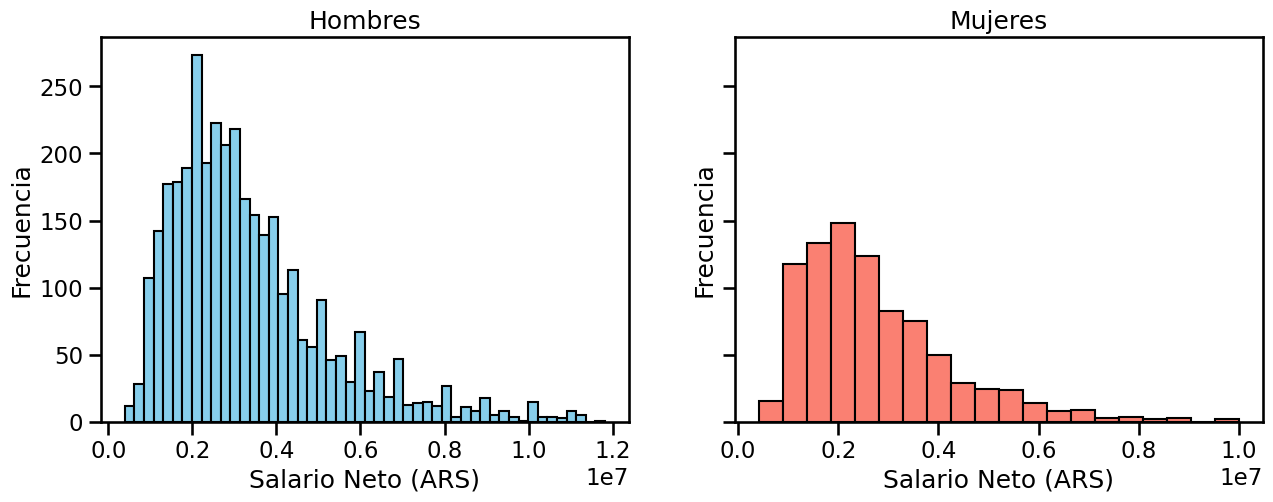

In [14]:
# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

# Plot each group on a separate subplot
axes[0].hist(groupA, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Hombres')
axes[0].set_xlabel('Salario Neto (ARS)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(groupB, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Mujeres')
axes[1].set_xlabel('Salario Neto (ARS)')
axes[1].set_ylabel('Frecuencia')

#### Analisis discriminado por seniority

In [15]:
# Copia de df_bounded para no sobreescribir resultados
df_bounded_b = df_bounded.copy()

In [16]:
df_bounded_b.loc[:,'profile_g'] = df_bounded_b.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [17]:
# Segmentacion por seniority: Senior
df_senior = df_bounded_b[df_bounded_b["work_seniority"] == "Senior"]
man_senior = df_senior.profile_g == 'Varón cis'
woman_senior = df_senior.profile_g == 'Mujer cis'

groupA_s = df_senior[man_senior].salary_monthly_NETO
groupB_s  = df_senior[woman_senior].salary_monthly_NETO

# Descripción de arreglos

print("=" * 55)
print("HOMBRES SENIOR - SALARIO NETO")
print("=" * 55)
print(groupA_s.describe().round(0))

print("\n" + "=" * 55)
print("MUJERES SENIOR - SALARIO NETO")
print("=" * 55)
print(groupB_s.describe().round(0))

HOMBRES SENIOR - SALARIO NETO
count        2124.0
mean      3906001.0
std       2014601.0
min        390000.0
25%       2466500.0
50%       3500000.0
75%       4900000.0
max      11820000.0
Name: salary_monthly_NETO, dtype: float64

MUJERES SENIOR - SALARIO NETO
count         416.0
mean      3415709.0
std       1626761.0
min        600000.0
25%       2200000.0
50%       3161454.0
75%       4221692.0
max      10000000.0
Name: salary_monthly_NETO, dtype: float64


Estimacion puntual + IC95% (Senior)

In [18]:
alpha = 0.05  # Nivel de significación (1 - alpha = 95% confianza)

# Calcular medias y desviaciones estándar
x_h = np.mean(groupA_s)  # Media hombres
x_m = np.mean(groupB_s)  # Media mujeres
s_h = np.std(groupA_s, ddof=1)  # Desviación estándar hombres
s_m = np.std(groupB_s, ddof=1)  # Desviación estándar mujeres
n_h = len(groupA_s)  # Tamaño muestral hombres
n_m = len(groupB_s)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Hombres - Mujeres): {diff_medias:.4f}")

# Intervalo de confianza usando t de Welch (no asume varianzas iguales)
# Error estándar de la diferencia
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad (aproximación de Welch)
df = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1)))

# Valor crítico para el intervalo de confianza
t_crit = stats.t.ppf(1 - alpha / 2, df)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error
print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Estimación puntual de la diferencia de medias (Hombres - Mujeres): 490291.7184
Intervalo de confianza al 95.0%: (311715.72, 668867.72)


Diferencia entre medias obtenida de $490K (Senior).

IC95% = [311715.72, 668867.72]

In [19]:
# Test de hipotesis considerando varianzas distintas
stats.ttest_ind(groupA_s, groupB_s, equal_var=False)

TtestResult(statistic=np.float64(5.390666471260452), pvalue=np.float64(9.649168895571747e-08), df=np.float64(689.5961353321495))

In [21]:
if stats.ttest_ind(groupA_s, groupB_s, equal_var=False)[1] < alpha :
    print("Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial")

else:
    print('No se puede rechazar la hipótesis nula debido a la falta de evidencia')

Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial


In [22]:
# Potencia del test
effect_size_s = (groupA_s.mean() - groupB_s.mean()) / groupB_s.std()
ratio_s = len(groupB_s) / len(groupA_s)
power_s= 0.8

obs1_s = tt_ind_solve_power(effect_size=effect_size_s, alpha=alpha, power=power_s,  ratio=ratio_s)

print(f"Numero de observaciones de hombres semi-senior requerida: {obs1_s:.0f}")
print(f"Numero de observaciones de mujeres semi-senior requerida: {obs1_s*ratio_s:.0f}")

Numero de observaciones de hombres semi-senior requerida: 529
Numero de observaciones de mujeres semi-senior requerida: 104


In [23]:
# Segmentacion por seniority: Semi-Senior
df_bounded_c = df_bounded.copy()

df_semi_senior = df_bounded_c[df_bounded_c["work_seniority"] == "Semi-Senior"]
man_semi_senior = df_semi_senior.profile_g == 'Varón cis'
woman_semi_senior = df_semi_senior.profile_g == 'Mujer cis'

groupA_ss = df_semi_senior[man_semi_senior].salary_monthly_NETO
groupB_ss  = df_semi_senior[woman_semi_senior].salary_monthly_NETO

# Descripción de arreglos

print("=" * 55)
print("HOMBRES SEMI-SENIOR - SALARIO NETO")
print("=" * 55)
print(groupA_ss.describe().round(0))

print("\n" + "=" * 55)
print("MUJERES SEMI-SENIOR - SALARIO NETO")
print("=" * 55)
print(groupB_ss.describe().round(0))

HOMBRES SEMI-SENIOR - SALARIO NETO
count        1028.0
mean      2670734.0
std       1330495.0
min        422227.0
25%       1800000.0
50%       2424158.0
75%       3200000.0
max      11268613.0
Name: salary_monthly_NETO, dtype: float64

MUJERES SEMI-SENIOR - SALARIO NETO
count        330.0
mean     2335886.0
std      1133880.0
min       423000.0
25%      1500000.0
50%      2105000.0
75%      2879000.0
max      8000000.0
Name: salary_monthly_NETO, dtype: float64


In [24]:
alpha = 0.05  # Nivel de significación (1 - alpha = 95% confianza)

# Calcular medias y desviaciones estándar
x_h = np.mean(groupA_ss)  # Media hombres
x_m = np.mean(groupB_ss)  # Media mujeres
s_h = np.std(groupA_ss, ddof=1)  # Desviación estándar hombres
s_m = np.std(groupB_ss, ddof=1)  # Desviación estándar mujeres
n_h = len(groupA_ss)  # Tamaño muestral hombres
n_m = len(groupB_ss)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Hombres - Mujeres): {diff_medias:.4f}")

# Intervalo de confianza usando t de Welch (no asume varianzas iguales)
# Error estándar de la diferencia
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad (aproximación de Welch)
df = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1)))

# Valor crítico para el intervalo de confianza
t_crit = stats.t.ppf(1 - alpha / 2, df)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error
print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Estimación puntual de la diferencia de medias (Hombres - Mujeres): 334848.0485
Intervalo de confianza al 95.0%: (187665.38, 482030.72)


Diferencia entre medias obtenida de $335K (Semi-Senior).

IC95% = [187665.38, 482030.72]

In [25]:
# Test de hipotesis considerando varianzas distintas
stats.ttest_ind(groupA_ss, groupB_ss, equal_var=False)

TtestResult(statistic=np.float64(4.467416000691089), pvalue=np.float64(9.351613057629712e-06), df=np.float64(643.8104690748601))

In [26]:
if stats.ttest_ind(groupA_ss, groupB_ss, equal_var=False)[1] < alpha :
    print("Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial")

else:
    print('No se puede rechazar la hipótesis nula debido a la falta de evidencia')

Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial


In [27]:
# Potencia del test
effect_size_ss = (groupA_ss.mean() - groupB_ss.mean()) / groupB_ss.std()
ratio_ss = len(groupB_ss) / len(groupA_ss)
power_ss= 0.8

obs1_ss = tt_ind_solve_power(effect_size=effect_size_ss, alpha=alpha, power=power_ss,  ratio=ratio_ss)

print(f"Numero de observaciones de hombres semi-senior requerida: {obs1_ss:.0f}")
print(f"Numero de observaciones de mujeres semi-senior requerida: {obs1_ss*ratio_ss:.0f}")

Numero de observaciones de hombres semi-senior requerida: 372
Numero de observaciones de mujeres semi-senior requerida: 119


In [28]:
# Segmentacion por seniority: Junior
df_bounded_d = df_bounded.copy()

df_junior = df_bounded_d[df_bounded_d["work_seniority"] == "Junior"]
man_junior = df_junior.profile_g == 'Varón cis'
woman_junior = df_junior.profile_g == 'Mujer cis'

groupA_j = df_junior[man_junior].salary_monthly_NETO
groupB_j  = df_junior[woman_junior].salary_monthly_NETO

# Descripción de arreglos

print("=" * 55)
print("HOMBRES JUNIOR - SALARIO NETO")
print("=" * 55)
print(groupA_j.describe().round(0))

print("\n" + "=" * 55)
print("MUJERES JUNIOR - SALARIO NETO")
print("=" * 55)
print(groupB_j.describe().round(0))

HOMBRES JUNIOR - SALARIO NETO
count        321.0
mean     1794311.0
std       936148.0
min       500000.0
25%      1140000.0
50%      1508000.0
75%      2200000.0
max      6300000.0
Name: salary_monthly_NETO, dtype: float64

MUJERES JUNIOR - SALARIO NETO
count        124.0
mean     1718131.0
std       811227.0
min       415000.0
25%      1165750.0
50%      1508225.0
75%      2067555.0
max      7250000.0
Name: salary_monthly_NETO, dtype: float64


In [29]:
alpha = 0.05  # Nivel de significación (1 - alpha = 95% confianza)

# Calcular medias y desviaciones estándar
x_h = np.mean(groupA_j)  # Media hombres
x_m = np.mean(groupB_j)  # Media mujeres
s_h = np.std(groupA_j, ddof=1)  # Desviación estándar hombres
s_m = np.std(groupB_j, ddof=1)  # Desviación estándar mujeres
n_h = len(groupA_j)  # Tamaño muestral hombres
n_m = len(groupB_j)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Hombres - Mujeres): {diff_medias:.4f}")

# Intervalo de confianza usando t de Welch (no asume varianzas iguales)
# Error estándar de la diferencia
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad (aproximación de Welch)
df = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1)))

# Valor crítico para el intervalo de confianza
t_crit = stats.t.ppf(1 - alpha / 2, df)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error
print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Estimación puntual de la diferencia de medias (Hombres - Mujeres): 76180.5327
Intervalo de confianza al 95.0%: (-100366.70, 252727.77)


Diferencia entre medias obtenida de $335K (Junior).

IC95% = [-100366.70, 252727.77]

In [30]:
# Test de hipotesis considerando varianzas distintas
stats.ttest_ind(groupA_j, groupB_j, equal_var=False)

TtestResult(statistic=np.float64(0.8497453282703696), pvalue=np.float64(0.3962605060780392), df=np.float64(256.05282119706686))

In [31]:
if stats.ttest_ind(groupA_j, groupB_j, equal_var=False)[1] < alpha :
    print("Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial")

else:
    print("No se puede rechazar la hipótesis nula debido a la falta de evidencia")

No se puede rechazar la hipótesis nula debido a la falta de evidencia


In [32]:
# Potencia del test
effect_size_j = (groupA_j.mean() - groupB_j.mean()) / groupB_j.std()
ratio_j = len(groupB_j) / len(groupA_j)
power_j= 0.8

obs1_j = tt_ind_solve_power(effect_size=effect_size_j, alpha=alpha, power=power_j,  ratio=ratio_j)

print(f"Numero de observaciones de hombres junior requerida: {obs1_j:.0f}")
print(f"Numero de observaciones de mujeres junior requerida: {obs1_j*ratio_j:.0f}")

Numero de observaciones de hombres junior requerida: 3195
Numero de observaciones de mujeres junior requerida: 1234


# PARENTESIS: Pruebo segmentar por seniority y puesto de trabajo concreto para ver si la brecha se sostiene

In [33]:
df = pd.read_csv(url)
df_raw_test = df.copy()

rel_col = ['salary_monthly_BRUTO', 'salary_monthly_NETO',
           'work_dedication', 'work_seniority', 'profile_gender',
           'profile_age', 'company_main_activity']

In [34]:
# Limpieza sobre columnas relevantes
df_raw_test = df_raw_test.drop_duplicates()
df_raw_test = df_raw_test.dropna(subset=rel_col)
df_raw_test[rel_col].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4938
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   salary_monthly_BRUTO   4715 non-null   float64
 1   salary_monthly_NETO    4715 non-null   float64
 2   work_dedication        4715 non-null   object 
 3   work_seniority         4715 non-null   object 
 4   profile_gender         4715 non-null   object 
 5   profile_age            4715 non-null   int64  
 6   company_main_activity  4715 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 294.7+ KB


In [35]:
# Quiero ver que puestos laborales tienen mayor frecuencia
df_raw_test.company_main_activity.value_counts()

,count
company_main_activity,
Developer,1588
SysAdmin / DevOps / SRE,525
Manager / Director,427
Technical Leader,337
QA / Tester,231
...,...
Service Delivery Analist,1
Tech Engineer sr,1
"SME z/OS, Mq y PGM PROD",1


In [36]:
# Limpieza de extremos con percentiles (1% superior e inferior)
p01 = df_raw_test['salary_monthly_NETO'].quantile(0.01)
p99 = df_raw_test['salary_monthly_NETO'].quantile(0.99)

df_bounded_t = df_raw_test[
    (df_raw_test['salary_monthly_NETO'] >= p01) &
    (df_raw_test['salary_monthly_NETO'] <= p99)
].copy()

# Consideramos dedicacion Full-Time unicamente
df_bounded_t = df_bounded_t.drop(df_bounded_t[df_bounded_t["work_dedication"] == "Part-Time"].index)

In [37]:
df_bounded_t.loc[:,'profile_g'] = df_bounded_t.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [38]:
# Me restrinjo al analisis de perfiles developer (mas numeroso)
df_developer = df_bounded_t[df_bounded_t['company_main_activity'] == 'Developer'].copy()

In [39]:
# Segmentacion por seniority: Senior
df_dev_s = df_developer[df_developer["work_seniority"] == "Senior"]
man_dev_s = df_dev_s.profile_g == 'Varón cis'
woman_dev_s = df_dev_s.profile_g == 'Mujer cis'

groupA_dev_s = df_dev_s[man_dev_s].salary_monthly_NETO
groupB_dev_s  = df_dev_s[woman_dev_s].salary_monthly_NETO

# Descripción de arreglos

print("=" * 55)
print("HOMBRES SENIOR - SALARIO NETO")
print("=" * 55)
print(groupA_dev_s.describe().round(0))

print("\n" + "=" * 55)
print("MUJERES SENIOR - SALARIO NETO")
print("=" * 55)
print(groupB_dev_s.describe().round(0))

HOMBRES SENIOR - SALARIO NETO
count         645.0
mean      3897203.0
std       1936359.0
min        400000.0
25%       2582144.0
50%       3446805.0
75%       4612151.0
max      11330000.0
Name: salary_monthly_NETO, dtype: float64

MUJERES SENIOR - SALARIO NETO
count          87.0
mean      3446366.0
std       1762802.0
min        800000.0
25%       2420000.0
50%       3200000.0
75%       3942500.0
max      10000000.0
Name: salary_monthly_NETO, dtype: float64


In [40]:
alpha = 0.05  # Nivel de significación (1 - alpha = 95% confianza)

# Calcular medias y desviaciones estándar
x_h = np.mean(groupA_dev_s)  # Media hombres
x_m = np.mean(groupB_dev_s)  # Media mujeres
s_h = np.std(groupA_dev_s, ddof=1)  # Desviación estándar hombres
s_m = np.std(groupB_dev_s, ddof=1)  # Desviación estándar mujeres
n_h = len(groupA_dev_s)  # Tamaño muestral hombres
n_m = len(groupB_dev_s)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Hombres - Mujeres): {diff_medias:.2f}")

# Intervalo de confianza usando t de Welch (no asume varianzas iguales)
# Error estándar de la diferencia
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad (aproximación de Welch)
df = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1)))

# Valor crítico para el intervalo de confianza
t_crit = stats.t.ppf(1 - alpha / 2, df)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error
print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Estimación puntual de la diferencia de medias (Hombres - Mujeres): 450837.20
Intervalo de confianza al 95.0%: (47196.18, 854478.22)


In [41]:
# Test de hipotesis considerando varianzas distintas
stats.ttest_ind(groupA_dev_s, groupB_dev_s, equal_var=False)

TtestResult(statistic=np.float64(2.2122408549011783), pvalue=np.float64(0.028911104597456286), df=np.float64(115.86132359469092))

In [42]:
if stats.ttest_ind(groupA_dev_s, groupB_dev_s, equal_var=False)[1] < alpha :
    print("Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial")

else:
    print("No se puede rechazar la hipótesis nula debido a la falta de evidencia")

Rechazo de hipótesis nula. Hay evidencia suficiente para afirmar que existe brecha salarial


In [43]:
# Potencia del test
effect_size_dev_s = (groupA_dev_s.mean() - groupB_dev_s.mean()) / groupB_dev_s.std()
ratio_dev_s = len(groupB_dev_s) / len(groupA_dev_s)
power_dev_s= 0.8

obs1_dev_s = tt_ind_solve_power(effect_size=effect_size_dev_s, alpha=alpha, power=power_dev_s,  ratio=ratio_dev_s)

print(f"Numero de observaciones de hombres junior requerida: {obs1_dev_s:.0f}")
print(f"Numero de observaciones de mujeres junior requerida: {obs1_dev_s*ratio_dev_s:.0f}")

Numero de observaciones de hombres junior requerida: 1011
Numero de observaciones de mujeres junior requerida: 136


## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0 = $ Media salarial neta de hombres **igual** a la de mujeres

$H_1 = $ Media salarial neta de hombres **distinta** a la de mujeres

**Estadístico (Pivote)**
  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$

El pivote es el correspondiente al test para igualdad de medias con varianzas distintas y muestras independientes.


### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

In [ ]:
effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
# nobs1=None  - What we want to know
alpha = 0.05
ratio = len(groupB) / len(groupA)
power= 0.8

In [ ]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

163.1896108369031

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.


# Graficos

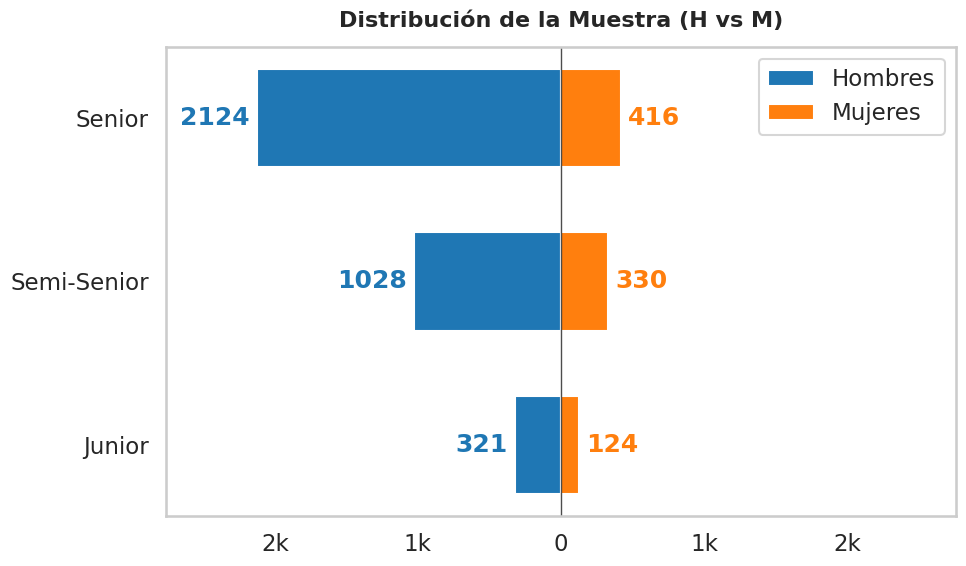

In [50]:
# Datos
data_p = {
    'Seniority': ['Junior', 'Semi-Senior', 'Senior'],
    'Hombres': [321, 1028, 2124],
    'Mujeres': [124, 330, 416]
}
df = pd.DataFrame(data_p)

# Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("white")

# Definir el límite del eje para centrar (basado en el máximo valor + margen)
max_val = df['Hombres'].max() * 1.30

# Dibujar barras
ax.barh(df['Seniority'], -df['Hombres'], color='#1f77b4', label='Hombres', height=0.6)
ax.barh(df['Seniority'], df['Mujeres'], color='#ff7f0e', label='Mujeres', height=0.6)

# Centrar el eje X: Limites iguales en ambos lados
ax.set_xlim(-max_val, max_val)

# Eje X invisible pero con etiquetas absolutas
ax.set_xticks([-2000, -1000, 0, 1000, 2000])
ax.set_xticklabels(['2k', '1k', '0', '1k', '2k'])

# Encuadrar el gráfico: Mantener los bordes para dar estructura
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#CCCCCC') # Gris suave para no competir con los datos

# Línea central divisoria
ax.axvline(0, color='black', linewidth=1, alpha=0.7)

# Etiquetas de datos para mayor claridad
for i, (h, m) in enumerate(zip(df['Hombres'], df['Mujeres'])):
    ax.text(-h - 50, i, str(h), va='center', ha='right', color='#1f77b4', fontweight='bold')
    ax.text(m + 50, i, str(m), va='center', ha='left', color='#ff7f0e', fontweight='bold')

plt.title("Distribución de la Muestra (H vs M)", fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()